# Issue #3 — Modelagem: Treinamento do Modelo Preditivo
Treina Random Forest e XGBoost para classificar `nivel_risco` (4 classes). Salva o melhor modelo em `models/risk_model.pkl`.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
    print('XGBoost disponível!')
except ImportError:
    XGBOOST_OK = False
    print('XGBoost não instalado. Rodando só Random Forest e Logistic Regression.')
    print('Para instalar: pip install xgboost')

XGBoost não instalado. Rodando só Random Forest e Logistic Regression.
Para instalar: pip install xgboost


## 1. Carregar dados do banco

In [2]:
DB_PATH = '../../sompo.db'

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql('SELECT * FROM telemetria', conn)
conn.close()

print(f'Dataset carregado: {df.shape}')
print(f'Colunas: {df.columns.tolist()}')

Dataset carregado: (1000, 35)
Colunas: ['id_registro', 'id_equipamento', 'data_hora', 'latitude', 'longitude', 'tipo_operacao', 'proximidade_agua_m', 'precipitacao_mm', 'umidade_solo_pct', 'tipo_solo', 'declividade_graus', 'temperatura_c', 'velocidade_vento_kmh', 'visibilidade_m', 'horas_uso_equipamento', 'dias_ultima_manutencao', 'velocidade_operacao_kmh', 'carga_pct', 'nivel_combustivel_pct', 'historico_incidentes', 'score_risco', 'nivel_risco', 'alerta_gerado', 'tipo_solo_encoded', 'tipo_operacao_encoded', 'faixa_proximidade_agua', 'faixa_proximidade_encoded', 'indice_desgaste', 'risco_solo', 'risco_atolamento', 'risco_operacional', 'risco_manutencao', 'score_risco_calculado', 'diff_score', 'data_ingestao']


## 2. Preparar features e target

In [3]:
TARGET = 'nivel_risco'

# Features numéricas disponíveis (baseado no Issue #1)
FEATURES_CANDIDATAS = [
    'proximidade_agua_m', 'precipitacao_mm', 'umidade_solo_pct',
    'declividade_graus', 'horas_uso_equipamento', 'dias_ultima_manutencao',
    'velocidade_operacao_kmh', 'carga_pct', 'historico_incidentes',
    'risco_manutencao', 'indice_desgaste', 'tipo_solo_encoded',
    'faixa_proximidade_encoded'  # score_risco REMOVIDO: target deriva dele (leakage)
]

# Usa apenas as que existem no banco
FEATURES = [f for f in FEATURES_CANDIDATAS if f in df.columns]
print(f'Features selecionadas ({len(FEATURES)}): {FEATURES}')

# Remove linhas com nulos nas features ou target
df_clean = df[FEATURES + [TARGET]].dropna()
print(f'Registros após limpeza: {len(df_clean)} (removidos: {len(df) - len(df_clean)})')

X = df_clean[FEATURES]
y_raw = df_clean[TARGET]

# Codificar target (Baixo=0, Médio=1, Alto=2, Crítico=3)
ordem_classes = ['Baixo', 'Médio', 'Alto', 'Crítico']
le = LabelEncoder()
le.fit([c for c in ordem_classes if c in y_raw.unique()])
y = le.transform(y_raw)

print(f'\nDistribuição do target:')
for cls, idx in zip(le.classes_, range(len(le.classes_))):
    n = (y == idx).sum()
    print(f'  {cls} ({idx}): {n} registros ({n/len(y)*100:.1f}%)')

Features selecionadas (13): ['proximidade_agua_m', 'precipitacao_mm', 'umidade_solo_pct', 'declividade_graus', 'horas_uso_equipamento', 'dias_ultima_manutencao', 'velocidade_operacao_kmh', 'carga_pct', 'historico_incidentes', 'risco_manutencao', 'indice_desgaste', 'tipo_solo_encoded', 'faixa_proximidade_encoded']
Registros após limpeza: 1000 (removidos: 0)

Distribuição do target:
  Alto (0): 256 registros (25.6%)
  Baixo (1): 259 registros (25.9%)
  Crítico (2): 211 registros (21.1%)
  Médio (3): 274 registros (27.4%)


## 3. Split treino/teste (80/20 estratificado)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} registros')
print(f'Teste:  {X_test.shape[0]} registros')

Treino: 800 registros
Teste:  200 registros


## 4. Baseline — Regra simples por proximidade_agua_m

In [5]:
def baseline_predict(X, le):
    """Regra simples baseada na distância à água (conforme Issue #3)"""
    classes = le.classes_.tolist()
    preds = []
    for _, row in X.iterrows():
        dist = row.get('proximidade_agua_m', 999)
        if dist < 50:
            label = 'Crítico'
        elif dist < 200:
            label = 'Alto'
        elif dist < 500:
            label = 'Médio'
        else:
            label = 'Baixo'
        if label in classes:
            preds.append(le.transform([label])[0])
        else:
            preds.append(0)
    return np.array(preds)

y_baseline = baseline_predict(X_test, le)
acc_baseline = accuracy_score(y_test, y_baseline)
print(f'Acurácia do Baseline (regra simples): {acc_baseline:.4f} ({acc_baseline*100:.1f}%)')

Acurácia do Baseline (regra simples): 0.4900 (49.0%)


## 5. Treinamento dos modelos com Cross-Validation (k=5)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=5,
        random_state=42, n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42
    )
}

if XGBOOST_OK:
    modelos['XGBoost'] = XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        random_state=42, eval_metric='mlogloss', verbosity=0
    )

resultados_cv = {}

print('Treinando com Cross-Validation (k=5)...\n')
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    resultados_cv[nome] = scores
    print(f'{nome}:')
    print(f'  CV Acurácia: {scores.mean():.4f} ± {scores.std():.4f}')
    print(f'  Por fold:    {[round(s,4) for s in scores]}')

Treinando com Cross-Validation (k=5)...

Random Forest:
  CV Acurácia: 0.7737 ± 0.0365
  Por fold:    [0.7562, 0.7438, 0.8438, 0.75, 0.775]
Logistic Regression:
  CV Acurácia: 0.6013 ± 0.0242
  Por fold:    [0.6188, 0.5938, 0.6375, 0.5875, 0.5688]


## 6. Comparação visual dos modelos

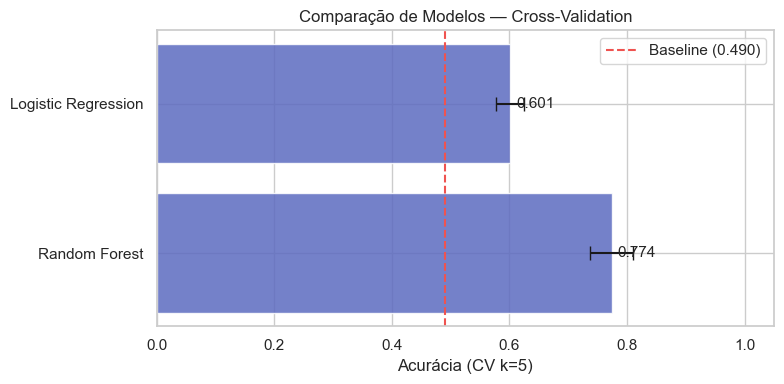

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(8, 4))

nomes = list(resultados_cv.keys())
medias = [v.mean() for v in resultados_cv.values()]
desvios = [v.std() for v in resultados_cv.values()]

bars = ax.barh(nomes, medias, xerr=desvios, color='#5C6BC0', alpha=0.85,
               capsize=5, edgecolor='white')
ax.axvline(acc_baseline, color='#EF5350', linestyle='--', label=f'Baseline ({acc_baseline:.3f})')
ax.set_xlabel('Acurácia (CV k=5)')
ax.set_title('Comparação de Modelos — Cross-Validation')
ax.set_xlim(0, 1.05)
ax.legend()

for bar, media in zip(bars, medias):
    ax.text(media + 0.01, bar.get_y() + bar.get_height()/2,
            f'{media:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('../../assets/ml_comparacao_modelos.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Treinar modelo final e salvar

In [8]:
# Escolha o melhor modelo com base no CV
melhor_nome = max(resultados_cv, key=lambda k: resultados_cv[k].mean())
print(f'Melhor modelo: {melhor_nome}')

modelo_final = modelos[melhor_nome]
modelo_final.fit(X_train, y_train)

# Acurácia no conjunto de teste
y_pred = modelo_final.predict(X_test)
acc_teste = accuracy_score(y_test, y_pred)
print(f'Acurácia no teste: {acc_teste:.4f} ({acc_teste*100:.1f}%)')

# Salvar modelo + metadados
artefato = {
    'model': modelo_final,
    'label_encoder': le,
    'features': FEATURES,
    'model_name': melhor_nome,
    'cv_accuracy_mean': resultados_cv[melhor_nome].mean(),
    'test_accuracy': acc_teste
}

with open('models/risk_model.pkl', 'wb') as f:
    pickle.dump(artefato, f)

print('\nModelo salvo em: src/ml/models/risk_model.pkl')

Melhor modelo: Random Forest
Acurácia no teste: 0.8400 (84.0%)

Modelo salvo em: src/ml/models/risk_model.pkl


## 8. Justificativa dos algoritmos
- **Random Forest**: Ensemble robusto, lida bem com features mistas (numéricas + encoded), não precisa de normalização, retorna feature importance nativa. Boa baseline para dados tabulares.
- **XGBoost**: Boosting gradiente, geralmente supera Random Forest em datasets tabulares, suporte nativo a multiclasse, regularização L1/L2 embutida.
- **Logistic Regression**: Simples e interpretável, serve como referência. Pode ter desempenho inferior em relações não-lineares.
- **Baseline (regra simples)**: Classifica por `proximidade_agua_m` apenas. Se os modelos treinados não superam esse baseline, algo está errado na modelagem.